# Measuring Synaptic Connection Probability

In this notebook we use the [Allen Institute synaptic physiology dataset](https://portal.brain-map.org/explore/connectivity/synaptic-physiology) to measure synaptic connection probability and its relationship to cell subclass and intersomatic distance.

For an introduction to the Jupyter Notebook interface interface, try [Codeacademy: How To Use Jupyter Notebooks]( https://www.codecademy.com/articles/how-to-use-jupyter-notebooks) or [Jupyter Notebook Quick Start Guide](https://jupyter-notebook-beginner-guide.readthedocs.io/en/latest/what_is_jupyter.html).


In [1]:
import numpy as np
from aisynphys.database import SynphysDatabase
from aisynphys.cell_class import CellClass, classify_cells, classify_pairs
from aisynphys.connectivity import measure_connectivity, pair_was_probed

In [55]:
def print_connectivity_results(pre_class, post_class):
    print("Connectivity results for %s => %s" % (pre_class, post_class))
    print("  %d synapses found out of %d probed" % (
        results[pre_class, post_class]['n_connected'],
        results[pre_class, post_class]['n_probed'],
    ))
    print("  %0.2f%% connection probability" % (
        results[pre_class, post_class]['connection_probability'][0] * 100,
    ))
    print("     95%% confidence interval: %0.2f%%-%0.2f%%" % (
        results[pre_class, post_class]['connection_probability'][1] * 100,
        results[pre_class, post_class]['connection_probability'][2] * 100,
    ))
    print("  %0.2f%% distance-adjusted connection probability" % (
        results[pre_class, post_class]['adjusted_connectivity'][0] * 100,
    ))
    print("     95%% confidence interval: %0.2f%%-%0.2f%%" % (
        results[pre_class, post_class]['adjusted_connectivity'][1] * 100,
        results[pre_class, post_class]['adjusted_connectivity'][2] * 100,
    ))

### 1. Load the data

First, load up the "small" database from release 1.0 and query all cell `pairs` for mouse projects.

In [ ]:
# Download and cache the sqlite file for the requested database
#   (for available versions, see SynphysDatabase.list_versions)
db = SynphysDatabase.load_current('small')

# Load all cell pairs associated with mouse V1 projects
mouse_pairs = db.pair_query(project_name=["mouse V1 coarse matrix", "mouse V1 pre-production"]).all()

print("loaded %d cell pairs" % len(mouse_pairs))

loaded 82818 cell pairs


A single cell `pair` represents a _possible_ connection from one cell to another:

In [3]:
# print some information about the last cell pair returned
pair = mouse_pairs[-1]
print("Cell pair:", pair)
print("  presynaptic subclass:", pair.pre_cell.cre_type)
print("  postsynaptic subclass:", pair.post_cell.cre_type)
print("  synaptic connection:", "yes" if pair.has_synapse else "no")

Cell pair: <Pair 1501104688.886 8 7>
  presynaptic subclass: unknown
  postsynaptic subclass: unknown
  synaptic connection: no


### 2. Define cell _classes_

We want to group together all cell pairs based on their pre- and postsynaptic cell classes. However, there are many different ways to classify cells so we must first define the criteria for all cell classes that we want to compare:

In [4]:
cell_class_criteria = {
    'l23pyr': {'dendrite_type': 'spiny',       'cortical_layer': '2/3'},
    'l23pv':  {'cre_type': 'pvalb',            'cortical_layer': '2/3'},
    'l23sst': {'cre_type': 'sst',              'cortical_layer': '2/3'},
    'l23vip': {'cre_type': 'vip',              'cortical_layer': '2/3'},
    'l4pyr':  {'cre_type': ('nr5a1', 'rorb'),  'cortical_layer': '4'},
    'l4pv':   {'cre_type': 'pvalb',            'cortical_layer': '4'},
    'l4sst':  {'cre_type': 'sst',              'cortical_layer': '4'},
    'l4vip':  {'cre_type': 'vip',              'cortical_layer': '4'},
    'l5et':   {'cre_type': ('sim1', 'fam84b'), 'cortical_layer': '5'},
    'l5it':   {'cre_type': 'tlx3',             'cortical_layer': '5'}, 
    'l5pv':   {'cre_type': 'pvalb',            'cortical_layer': '5'},
    'l5sst':  {'cre_type': 'sst',              'cortical_layer': '5'},
    'l5vip':  {'cre_type': 'vip',              'cortical_layer': '5'},
    'l6pyr':  {'cre_type': 'ntsr1',            'cortical_layer': ('6a','6b')},
    'l6pv':   {'cre_type': 'pvalb',            'cortical_layer': ('6a','6b')},
    'l6sst':  {'cre_type': 'sst',              'cortical_layer': ('6a','6b')},
    'l6vip':  {'cre_type': 'vip',              'cortical_layer': ('6a','6b')},
}

Create a `CellClass` object to represent each cell class described above:

In [5]:
cell_classes = {name:CellClass(name=name, **criteria) for name,criteria in cell_class_criteria.items()}

### 3. Measure connection probability between classes

In [6]:
# Group all cells by selected classes
cell_groups = classify_cells(cell_classes.values(), pairs=mouse_pairs)

# Group pairs into (pre_class, post_class) groups
pair_groups = classify_pairs(mouse_pairs, cell_groups)

# analyze matrix elements
results = measure_connectivity(pair_groups, sigma=100e-6, dist_measure='lateral_distance')

/home/luke/docs/aisynphys/aisynphys/connectivity.py:356: RuntimeWarning: Mean of empty slice.
  mean_cp = np.exp(-x_probed**2 / (2 * sigma**2)).mean()
/home/luke/miniconda3/envs/py3/lib/python3.8/site-packages/numpy/core/_methods.py:161: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/home/luke/docs/aisynphys/aisynphys/connectivity.py:362: RuntimeWarning: invalid value encountered in long_scalars
  est_pmax = (n_conn / n_test) / mean_cp


At this point we have all data loaded and connection probabilities have been computed. For each combination of (presynaptic_class, postsynaptic_class), we have a result dictionary that includes the number of putative connections probed, the number of synapses found, and the connection probability with 95% confidence intervals.

**The results for a single connection type look like:**

In [7]:
# pick two arbitrary cell classes to display results from
pre_class = cell_classes['l23sst']
post_class = cell_classes['l23vip']

print("Connectivity results for %s => %s" % (pre_class, post_class))
print("  %d synapses found out of %d probed" % (
    results[pre_class, post_class]['n_connected'],
    results[pre_class, post_class]['n_probed'],
))
print("  %0.2f%% connection probability" % (
    results[pre_class, post_class]['connection_probability'][0] * 100,
))
print("     95%% confidence interval: %0.2f%%-%0.2f%%" % (
    results[pre_class, post_class]['connection_probability'][1] * 100,
    results[pre_class, post_class]['connection_probability'][2] * 100,
))
print("  %0.2f%% distance-adjusted connection probability" % (
    results[pre_class, post_class]['adjusted_connectivity'][0] * 100,
))
print("     95%% confidence interval: %0.2f%%-%0.2f%%" % (
    results[pre_class, post_class]['adjusted_connectivity'][1] * 100,
    results[pre_class, post_class]['adjusted_connectivity'][2] * 100,
))
    

Connectivity results for l23sst => l23vip
  12 synapses found out of 32 probed
  37.50% connection probability
     95% confidence interval: 21.10%-56.31%
  49.12% distance-adjusted connection probability
     95% confidence interval: 27.64%-73.75%


### 4. Display conectivity heat map

Now we want to take the entire set of results computed above (for all connection types) and display a heat map where the color represents the probability of connection. 

To do this, we must first transform the results into 2D arrays of colors and labels, and then construct the heat map with a few calls to matplotlib. The function defined below 

KeyError: 'adjusted_connectivity'

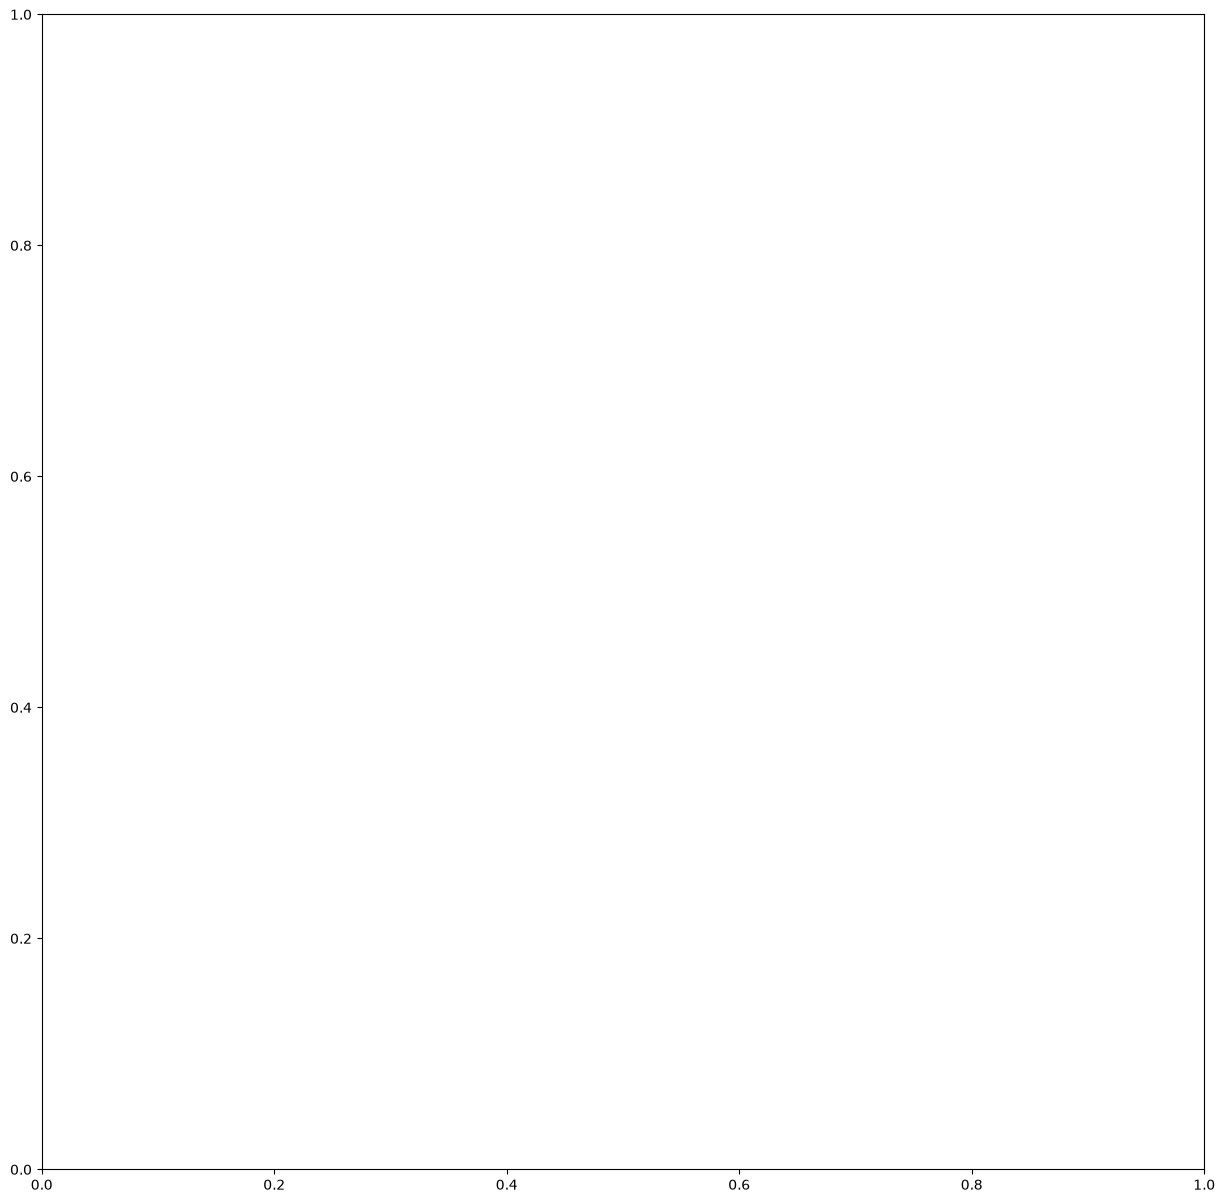

In [11]:
import matplotlib.colors, matplotlib.cm
import matplotlib.pyplot as plt
from aisynphys.ui.notebook import show_connectivity_matrix
%matplotlib inline

# define a colormap and log normalization used to color the heatmap
norm = matplotlib.colors.LogNorm(vmin=0.01, vmax=1.0, clip=True)
cmap = matplotlib.colormaps['plasma']

# define the display labels to use for each cell subclass:
class_labels = {
    'l23pyr': 'L2/3 Pyr\nspiny',
    'l23pv':  'L2/3 Pv',
    'l23sst': 'L2/3 Sst',
    'l23vip': 'L2/3 Vip',
    'l4pyr':  'L4 Pyr\n nr5a1',
    'l4pv':   'L4 Pv',
    'l4sst':  'L4 Sst',
    'l4vip':  'L4 Vip',
    'l5et':   'L5 Pyr ET\nsim1, fam84b',
    'l5it':   'L5 Pyr IT\ntlx3',
    'l5pv':   'L5 Pv',
    'l5sst':  'L5 Sst',
    'l5vip':  'L5 Vip',
    'l6pyr':  'L6 Pyr\nntsr1',
    'l6pv':   'L6 Pv',
    'l6sst':  'L6 Sst',
    'l6vip':  'L6 Vip',
}

# create a figure/axes to draw on
fig, ax = plt.subplots(figsize=(15, 15))

# finally, draw the colormap using the provided function:
im, cbar, labels = show_connectivity_matrix(
    ax=ax, 
    results=results, 
    pre_cell_classes=cell_classes.values(), 
    post_cell_classes=cell_classes.values(), 
    class_labels=class_labels, 
    cmap=cmap, 
    norm=norm,
    distance_adjusted=True
)

In [9]:
# pick two arbitrary cell classes to display results from
pre_class = cell_classes['l5vip']
post_class = cell_classes['l23vip']
#post_class = cell_classes['l4pyr']

print("Connectivity results for %s => %s" % (pre_class, post_class))
print("  %d synapses found out of %d probed" % (
    results[pre_class, post_class]['n_connected'],
    results[pre_class, post_class]['n_probed'],
))
print("  %0.2f%% connection probability" % (
    results[pre_class, post_class]['connection_probability'][0] * 100,
))
print("     95%% confidence interval: %0.2f%%-%0.2f%%" % (
    results[pre_class, post_class]['connection_probability'][1] * 100,
    results[pre_class, post_class]['connection_probability'][2] * 100,
))
print("  %0.2f%% distance-adjusted connection probability" % (
    results[pre_class, post_class]['adjusted_connectivity'][0] * 100,
))
print("     95%% confidence interval: %0.2f%%-%0.2f%%" % (
    results[pre_class, post_class]['adjusted_connectivity'][1] * 100,
    results[pre_class, post_class]['adjusted_connectivity'][2] * 100,
))
d = [p.distance for p in results[pre_class, post_class]['probed_pairs']]
print(np.mean(d))

Connectivity results for l5vip => l23vip
  0 synapses found out of 23 probed
  0.00% connection probability
     95% confidence interval: 0.00%-14.82%
  0.00% distance-adjusted connection probability
     95% confidence interval: 0.00%-24.64%
0.0002956412760061835


In [10]:
# optionally we can save the figure at this point
fig.savefig('mouse_connectivity_matrix.svg', format='svg')

It's important to remember that the measurements of connection probability shown above come with confidence intervals -- for example, L2/3 Sst cells were interconnected 4 times out of 112 probed (3.6%), but there is a range of possible connection rates that are statistically compatible with our results:

In [11]:
l23sst = cell_classes['l23sst']
cp, ci_low, ci_high = results[l23sst, l23sst]['connection_probability']
print(ci_low, ci_high)

0.008716160791083906 0.07928800565262084


The 95% confidence intervals above suggest that the probability of connection between L2/3 Sst cells is likely to be in the range 1-9%. Keep this statistical uncertainty in mind when interpreting the results above, and use appropriate tests when making comparisons between groups.

## Connectivity in the human dataset

The synaptic physiology dataset also contains recordings from human brain tissue. However, this tissue lacks the transgenic markers that we used to define mouse cell classes above. Instead, we will rely entirely on cortical layer and dendritic morphology (specifically, the presence of dense spines associated with excitatory cells) to separate classes. 

In the example below we filter only for cells with spiny dendrites, although the dataset also contains a smaller number of inhibitory interneurons as well as pyramidal cells for which no biocytin fill was available to judge the dendrite type.

In [2]:
db = SynphysDatabase.load_current('small')

# Load all cell pairs associated with mouse V1 projects
human_pairs = db.pair_query(project_name=["human coarse matrix"]).all()

print("loaded %d cell pairs" % len(human_pairs))

loaded 10400 cell pairs


In [25]:
human_cells = {}

for pair in human_pairs:
    human_cells[pair.pre_cell.id] = pair.pre_cell
    human_cells[pair.post_cell.id] = pair.post_cell

human_cells = list(human_cells.values())

print(f"Number of human cells: {len(human_cells)}")

Number of human cells: 2004


In [26]:
for attr in [
    'cell_class',
    'cell_class_nonsynaptic',
    'cre_type',
    'cortical_layer',
    'dendrite_type',
]:
    print(f"\n========== {attr} ==========")

    values = set()

    for cell in human_cells:
        try:
            value = getattr(cell, attr)
            values.add(value)
        except AttributeError:
            pass

    for value in sorted(values, key=str):
        print(repr(value))



========== cell_class ==========
None
'ex'
'in'
'mixed'

========== cell_class_nonsynaptic ==========
None
'ex'
'in'

========== cre_type ==========
'unknown'

========== cortical_layer ==========

========== dendrite_type ==========


In [31]:
print(db.CorticalCellLocation.__table__.columns.keys())
print(db.Morphology.__table__.columns.keys())

['id', 'cell_id', 'cortical_site_id', 'cortical_layer', 'distance_to_pia', 'distance_to_wm', 'fractional_depth', 'layer_depth', 'layer_thickness', 'fractional_layer_depth', 'position', 'meta']
['id', 'cell_id', 'pyramidal', 'qual_morpho_type', 'dendrite_type', 'apical_trunc_distance', 'axon_trunc_distance', 'apical_truncation', 'axon_truncation', 'axon_origin', 'meta']


In [33]:
human_cell_ids = set()

for pair in human_pairs:
    human_cell_ids.add(pair.pre_cell.id)
    human_cell_ids.add(pair.post_cell.id)

print("Human cells:", len(human_cell_ids))

Human cells: 2004


In [35]:
layers = (
    db.session().query(db.CorticalCellLocation.cortical_layer)
    .filter(
        db.CorticalCellLocation.cell_id.in_(human_cell_ids)
    )
    .distinct()
    .all()
)

print("Human cortical layers:")
for x in layers:
    print(repr(x[0]))

Human cortical layers:
'2'
'3'
'4'
'5'
'6'
None
'1'


In [36]:
dendrites = (
    db.session().query(db.Morphology.dendrite_type)
    .filter(
        db.Morphology.cell_id.in_(human_cell_ids)
    )
    .distinct()
    .all()
)

print("Human dendrite types:")
for x in dendrites:
    print(repr(x[0]))

Human dendrite types:
None
'spiny'
'NEI'
'aspiny'
'sparsely spiny'


In [42]:
n_locations = (
    db.session()
    .query(db.CorticalCellLocation.cell_id)
    .filter(
        db.CorticalCellLocation.cell_id.in_(human_cell_ids)
    )
    .count()
)

print("Human cells with cortical locations:", n_locations)


Human cells with cortical locations: 1479


In [ ]:
cell_locations = (
    db.session().query(db.CorticalSite.brain_region)
    .filter(
        db.CorticalSite.id.in_(
            db.session().query(db.CorticalCellLocation.cortical_site_id)
            .filter(db.CorticalCellLocation.cell_id.in_(human_cell_ids))
        )
    )   
)
print("Human brain regions:")
for x in brain_regions:
    print(repr(x[0]))

In [46]:
cell_class_criteria = {
    'l2pyr':  {'dendrite_type': 'spiny', 'cortical_layer': '2'},
    'l3pyr':  {'dendrite_type': 'spiny', 'cortical_layer': '3'},
    'l4pyr':  {'dendrite_type': 'spiny', 'cortical_layer': '4'},
    'l5pyr':  {'dendrite_type': 'spiny', 'cortical_layer': '5'},
}

In [47]:
cell_classes = {name:CellClass(name=name, **criteria) for name,criteria in cell_class_criteria.items()}

In [29]:
# Group all cells by selected classes
cell_groups = classify_cells(cell_classes.values(), pairs=human_pairs)

# Group pairs into (pre_class, post_class) groups
pair_groups = classify_pairs(human_pairs, cell_groups)

# analyze matrix elements
results = measure_connectivity(pair_groups)

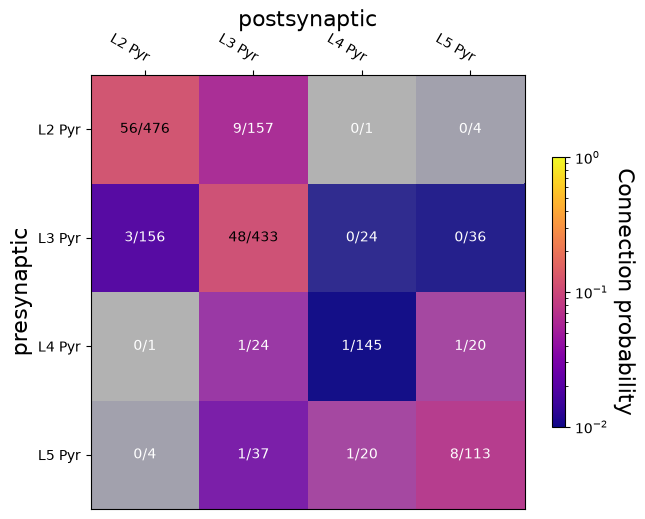

In [6]:
import matplotlib.colors, matplotlib.cm
import matplotlib.pyplot as plt
from aisynphys.ui.notebook import show_connectivity_matrix

# define a colormap and log normalization used to color the heatmap
norm = matplotlib.colors.LogNorm(vmin=0.01, vmax=1.0, clip=True)
cmap = matplotlib.colormaps['plasma']

class_labels = {
    'l2pyr':  'L2 Pyr',
    'l2int':  'L2 Inh',
    'l3pyr':  'L3 Pyr',
    'l3int':  'L3 Inh',
    'l4pyr':  'L4 Pyr',
    'l4int':  'L4 Inh',
    'l5pyr':  'L5 Pyr',
    'l5int':  'L5 Inh',
}

# create a figure/axes to draw on
fig, ax = plt.subplots(figsize=(7, 7))

# finally, draw the colormap using the provided function:
im, cbar, labels = show_connectivity_matrix(
    ax=ax, 
    results=results, 
    pre_cell_classes=cell_classes.values(), 
    post_cell_classes=cell_classes.values(),
    distance_adjusted=False,
    class_labels=class_labels, 
    cmap=cmap, 
    norm=norm
)
cbar.set_label("Connection probability", size=16)

In [49]:
cell_class_criteria = {
    'l2e':  {'cell_class': 'ex', 'cortical_layer': '2'},
    'l2i':  {'cell_class': 'in', 'cortical_layer': '2'},
    'l3e':  {'cell_class': 'ex', 'cortical_layer': '3'},
    'lei':  {'cell_class': 'in', 'cortical_layer': '3'},
}

In [50]:
class_labels = {
    'l2e':  'L2 Exc',
    'l2i':  'L2 Inh',
    'l3e':  'L3 Exc',
    'lei':  'L3 Inh',
}


cell_classes = {name:CellClass(name=name, **criteria) for name,criteria in cell_class_criteria.items()}
cell_groups = classify_cells(cell_classes.values(), pairs=human_pairs)
pair_groups = classify_pairs(human_pairs, cell_groups)
results = measure_connectivity(pair_groups, sigma=100e-6, dist_measure='lateral_distance')

/Users/mal/Documents/Neuroscience/OBI-dataloader/aisynphys-repo/aisynphys/connectivity.py:323: RuntimeWarning: Mean of empty slice
  mean_cp = np.exp(-x_probed**2 / (2 * sigma**2)).mean()
/opt/miniconda3/envs/aisynphys/lib/python3.14/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/Users/mal/Documents/Neuroscience/OBI-dataloader/aisynphys-repo/aisynphys/connectivity.py:329: RuntimeWarning: invalid value encountered in scalar divide
  est_pmax = (n_conn / n_test) / mean_cp


In [52]:
pre_class = cell_classes['l2e']
post_class = cell_classes['l2i']

print("Connectivity results for %s => %s" % (pre_class, post_class))
print("  %d synapses found out of %d probed" % (
    results[pre_class, post_class]['n_connected'],
    results[pre_class, post_class]['n_probed'],
))
print("  %0.2f%% connection probability" % (
    results[pre_class, post_class]['connection_probability'][0] * 100,
))
print("     95%% confidence interval: %0.2f%%-%0.2f%%" % (
    results[pre_class, post_class]['connection_probability'][1] * 100,
    results[pre_class, post_class]['connection_probability'][2] * 100,
))
print("  %0.2f%% distance-adjusted connection probability" % (
    results[pre_class, post_class]['adjusted_connectivity'][0] * 100,
))
print("     95%% confidence interval: %0.2f%%-%0.2f%%" % (
    results[pre_class, post_class]['adjusted_connectivity'][1] * 100,
    results[pre_class, post_class]['adjusted_connectivity'][2] * 100,
))


Connectivity results for l2e => l2i
  10 synapses found out of 41 probed
  24.39% connection probability
     95% confidence interval: 12.36%-40.30%
  29.80% distance-adjusted connection probability
     95% confidence interval: 15.10%-49.24%


In [57]:
print_connectivity_results(cell_classes['l2e'], cell_classes['l2i'])
print("------------------------")
print_connectivity_results(cell_classes['l2i'], cell_classes['l2e'])
print("------------------------")
print_connectivity_results(cell_classes['l2e'], cell_classes['l2e'])
print("------------------------")
print_connectivity_results(cell_classes['l2i'], cell_classes['l2i'])

Connectivity results for l2e => l2i
  10 synapses found out of 41 probed
  24.39% connection probability
     95% confidence interval: 12.36%-40.30%
  29.80% distance-adjusted connection probability
     95% confidence interval: 15.10%-49.24%
------------------------
Connectivity results for l2i => l2e
  2 synapses found out of 37 probed
  5.41% connection probability
     95% confidence interval: 0.66%-18.19%
  6.69% distance-adjusted connection probability
     95% confidence interval: 0.82%-22.53%
------------------------
Connectivity results for l2e => l2e
  60 synapses found out of 507 probed
  11.83% connection probability
     95% confidence interval: 9.15%-14.97%
  14.94% distance-adjusted connection probability
     95% confidence interval: 11.55%-18.89%
------------------------
Connectivity results for l2i => l2i
  0 synapses found out of 4 probed
  0.00% connection probability
     95% confidence interval: 0.00%-60.24%
  0.00% distance-adjusted connection probability
     95

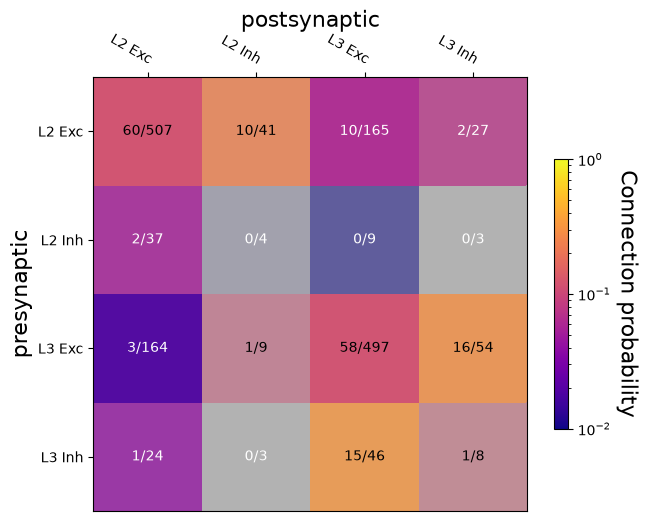

In [51]:
# create a figure/axes to draw on
fig, ax = plt.subplots(figsize=(7, 7))

# finally, draw the colormap using the provided function:
im, cbar, labels = show_connectivity_matrix(
    ax=ax, 
    results=results, 
    pre_cell_classes=cell_classes.values(), 
    post_cell_classes=cell_classes.values(),
    distance_adjusted=False,
    class_labels=class_labels, 
    cmap=cmap, 
    norm=norm
)
cbar.set_label("Connection probability", size=16)

## Connectivity vs intersomatic distance

It is generally understood that two cells are more likely to be connected if their cell bodies are close together. This introduces a possible source of systematic bias in the connectivity measurements shown above because we do not always probe for synapses over the same range of distances. If one matrix element above was probed at sorter distances than another, then it may appear to have higher connectivity when in fact this is only the result of a sampling bias.

To be more careful, we can look at the actual distribution of distances probed for each group to make a more fair comparison:

In [17]:
# sort all inhibitory cells into pv, sst,and vip subclasses
cell_classes = {
    'pv': CellClass(cre_type='pvalb'),
    'sst': CellClass(cre_type='sst'),
    'vip': CellClass(cre_type='vip'),
}
cell_groups = classify_cells(cell_classes.values(), pairs=mouse_pairs)
pair_groups = classify_pairs(mouse_pairs, cell_groups)

In [18]:
from aisynphys.connectivity import connectivity_profile

# 20 um bins
bin_edges = np.arange(0, 500e-6, 20e-6)

profiles = {}
distances = {}
connected = {}

# loop over all 3 cell classes 
for name, cell_class in cell_classes.items():
    # get all like->like pairs for this cell class
    pairs = pair_groups[cell_class, cell_class]
    
    # filter for pairs that were probed for inhibitory connections
    pairs = [pair for pair in pairs if pair_was_probed(pair, 'in')]
    
    # build an array describing whether each pair is connected
    connected[name] = np.array([pair.has_synapse for pair in pairs]).astype(bool)
    
    # and another list of distances
    distances[name] = np.array([pair.distance for pair in pairs]).astype(float)
    
    # generate a profile of connection probability vs distance 
    # with confidence intervals
    profiles[name] = connectivity_profile(connected[name], distances[name], bin_edges)
    
    

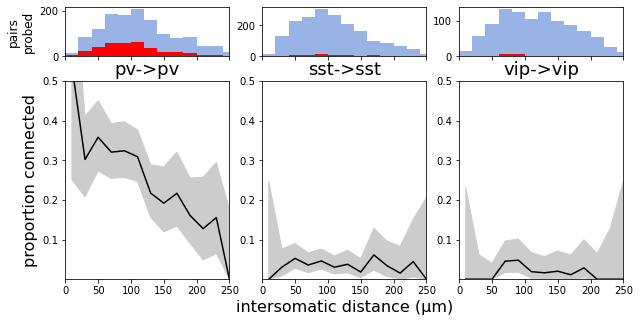

In [19]:
fig,axes = plt.subplots(2, 3, figsize=(10, 5), sharex=True, gridspec_kw={'height_ratios': [1, 4]})

for i,name in enumerate(profiles):
    bin_edges, prop, lower_ci, upper_ci = profiles[name]
    
    ax = axes[0, i]
    dist = distances[name]*1e6
    ax.hist(dist, bins=bin_edges*1e6, color=(0.6, 0.7, 0.9))
    ax.hist(dist[connected[name]], bins=bin_edges*1e6, color='red')
    
    xvals = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    ax = axes[1, i]
    ax.fill_between(xvals*1e6, lower_ci, upper_ci, color=(0.8, 0.8, 0.8))
    ax.plot(xvals*1e6, prop, color=(0, 0, 0))
    ax.set_ylim(0.001, 0.5)
    ax.set_xlim(0, 250)
    ax.set_title(name + "->" + name, size=18)
    

axes[0,0].set_ylabel('pairs\nprobed', size=12)
axes[1,0].set_ylabel('proportion connected', size=16)
axes[1,1].set_xlabel('intersomatic distance (µm)', size=16);

The plots above show much more frequent connectivity between pvalb-positive interneurons (in all layers) compared to sst and vip, regardless of the intersomatic distance. 